# Part 1: the carotenoid pathway inventory of *Colocasia esculenta*

Reads `results/tables/part1_inventory.tsv` and the two tables beside it.
Nothing is computed here that is not already in those files, and nothing is
written: every figure is displayed and none is saved. The analysis lives in
`scripts/`, the method in `docs/METHODS_part1.md`.

**What these figures encode, and why it is not gene counts.**

A bar chart of genes per pathway step would be the obvious figure and would
undo the method. The whole design separates three kinds of statement that a
count treats alike:

- a **copy number**, which needs a family assignment clearing support AND an
  independent locus on an anchored sequence
- a **detection count**, which is a lower bound because reciprocal best hit
  cannot see a paralog whose closest Arabidopsis relative lies outside the
  declared family
- a **presence** call, which asks only whether the gene exists

So the encoded variable is the `evidence` column, collapsed to an ordered
five-step ladder, and the claim kind is shown beside each target rather than
folded into the same colour.

**Colour.** One sequential blue hue for the ordered ladder, two categorical
hues for the two support statistics. Both were validated rather than eyeballed:

```
node scripts/validate_palette.js "#86b6ef,#5598e7,#2a78d6,#1c5cab,#0d366b" \
     --mode light --ordinal        # all checks pass; 5 is the maximum that does
node scripts/validate_palette.js "#2a78d6,#eb6834" --mode light --pairs all
                                   # worst pair CVD dE 24.7 protan, normal 33.6
```

Five tiers is not a preference. A six-step ramp fails the adjacent-lightness
check anywhere in this hue's usable band, so the ladder was collapsed to fit
what a reader can actually distinguish.

In [1]:
import os
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

CODE = Path(os.environ.get('TARO_CODE', Path.home() / 'Code' / 'taro'))
TBL  = CODE / 'results' / 'tables'

# ---- validated palette -------------------------------------------------
SURFACE   = '#fcfcfb'
INK       = '#0b0b0b'
INK_2     = '#52514e'
INK_MUTED = '#8a8880'
GRID      = '#e8e7e3'

# ordinal, one hue, light to dark: five steps, the maximum that clears the
# adjacent-lightness gate with the light end still above 2:1 on this surface
LADDER = ['#86b6ef', '#5598e7', '#2a78d6', '#1c5cab', '#0d366b']

# categorical slots 1 and 2, for the two support statistics
S1, S2 = '#2a78d6', '#eb6834'

# sequential ramp for the one heatmap, the documented 100-700 blue steps
SEQ = LinearSegmentedColormap.from_list('taro_blue', [
    '#cde2fb', '#9ec5f4', '#6da7ec', '#3987e5', '#256abf', '#184f95', '#0d366b'])

mpl.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'text.color': INK, 'axes.labelcolor': INK_2,
    'xtick.color': INK_2, 'ytick.color': INK_2,
    'axes.edgecolor': GRID, 'grid.color': GRID,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.linewidth': 0.8, 'xtick.major.width': 0.8, 'ytick.major.width': 0.8,
    'font.size': 9, 'axes.titlesize': 11, 'axes.titleweight': 'medium',
    'axes.titlelocation': 'left', 'axes.titlepad': 10,
    'legend.frameon': False, 'figure.dpi': 110,
})

inv  = pd.read_csv(TBL / 'part1_inventory.tsv', sep='\t')
sens = pd.read_csv(TBL / 'homology_sensitivity.tsv', sep='\t')
hits = pd.read_csv(TBL / 'homology_hits_all.tsv', sep='\t')
for col in ('tree_alrt', 'tree_boot', 'member_alrt', 'member_boot',
            'anchor_from', 'anchor_to', 'protein_aa', 'span_bp',
            'exons', 'counted', 'independent_locus'):
    inv[col] = pd.to_numeric(inv[col], errors='coerce')

# Pathway order, defined once here rather than inside a figure cell, so
# no figure depends on another figure having been run first.
PATH_ORDER = ['MEP', 'backbone', 'core', 'cyclase', 'xanth', 'degrade', 'sink']
ORDER = (inv[['pathway', 'target', 'claim_kind']].drop_duplicates()
            .assign(k=lambda d: d.pathway.map(
                {p: i for i, p in enumerate(PATH_ORDER)}))
            .sort_values(['k', 'target'], ascending=[False, False])
            .reset_index(drop=True))

print(f'{len(inv)} inventory rows, {inv.target.nunique()} targets')
missing = set(inv.pathway) - set(PATH_ORDER)
if missing:
    print(f'pathway values absent from PATH_ORDER, they will sort last: {missing}')

51 inventory rows, 28 targets


## The evidence ladder

Eleven distinct `evidence` strings collapse to five ordered tiers. The mapping
is printed in full so the collapse is auditable: a figure that hides which
strings were merged is a figure you cannot check.

The ladder is ordered **within a claim kind**, not across them. `present` for a
presence target is the complete claim that target ever asked for, and it sits
on the same rung as `candidate (RBH)` because it rests on the same evidence:
reciprocal homology with adequate coverage. Reading tier 2 as "worse than"
tier 5 across claim kinds would be reading the figure wrongly, which is why
claim kind is printed beside every target label.

In [2]:
TIERS = [
    ('recorded, not counted', [
        'sub-threshold hit, recorded not counted',
        'present, below the counting floor']),
    ('reciprocal homology', [
        'candidate (RBH)', 'present']),
    ('family assigned, copy number not established', [
        'family assigned; unanchored sequence',
        'family assigned; shared with',
        'family assigned; gene model length anomalous',
        'no tree; locus evidence only',
        'family assignment not determinable']),
    ('locus verified, support below threshold', [
        'locus verified, family support below threshold']),
    ('copy-number verified', [
        'copy-number verified']),
]

def tier_of(ev):
    for i, (_, prefixes) in enumerate(TIERS):
        if any(str(ev).startswith(p) for p in prefixes):
            return i
    return np.nan

inv['tier'] = inv.evidence.map(tier_of)

unmapped = inv[inv.tier.isna()]
if len(unmapped):
    print('UNMAPPED evidence strings, the ladder is incomplete:')
    print(unmapped.evidence.value_counts().to_string())
else:
    print('every evidence string maps to a tier\n')

for i, (name, _) in enumerate(TIERS):
    sub = inv[inv.tier == i]
    print(f'tier {i+1}  {name}   {len(sub)} rows')
    for ev, n in sub.evidence.value_counts().items():
        print(f'            {n:>3}  {ev}')

every evidence string maps to a tier

tier 1  recorded, not counted   9 rows
              9  sub-threshold hit, recorded not counted
tier 2  reciprocal homology   28 rows
             25  candidate (RBH)
              3  present
tier 3  family assigned, copy number not established   6 rows
              3  no tree; locus evidence only
              2  family assigned; unanchored sequence
              1  family assigned; gene model length anomalous, copy number not called
tier 4  locus verified, support below threshold   4 rows
              4  locus verified, family support below threshold
tier 5  copy-number verified   4 rows
              4  copy-number verified


## Figure 1. The pathway inventory

One row per target, in pathway order from the MEP precursor chain through to
the accumulation regulators. Bar length is the number of taro genes recovered;
segments are the evidence tier each gene reached. The bracket after each target
name is its claim kind, fixed before the search ran.

Read along a bar rather than at its length. DXS has the longest bar in the
figure and no copy number attached to it, because six of its ten genes are
sub-threshold fragments and the target was declared detection-only.

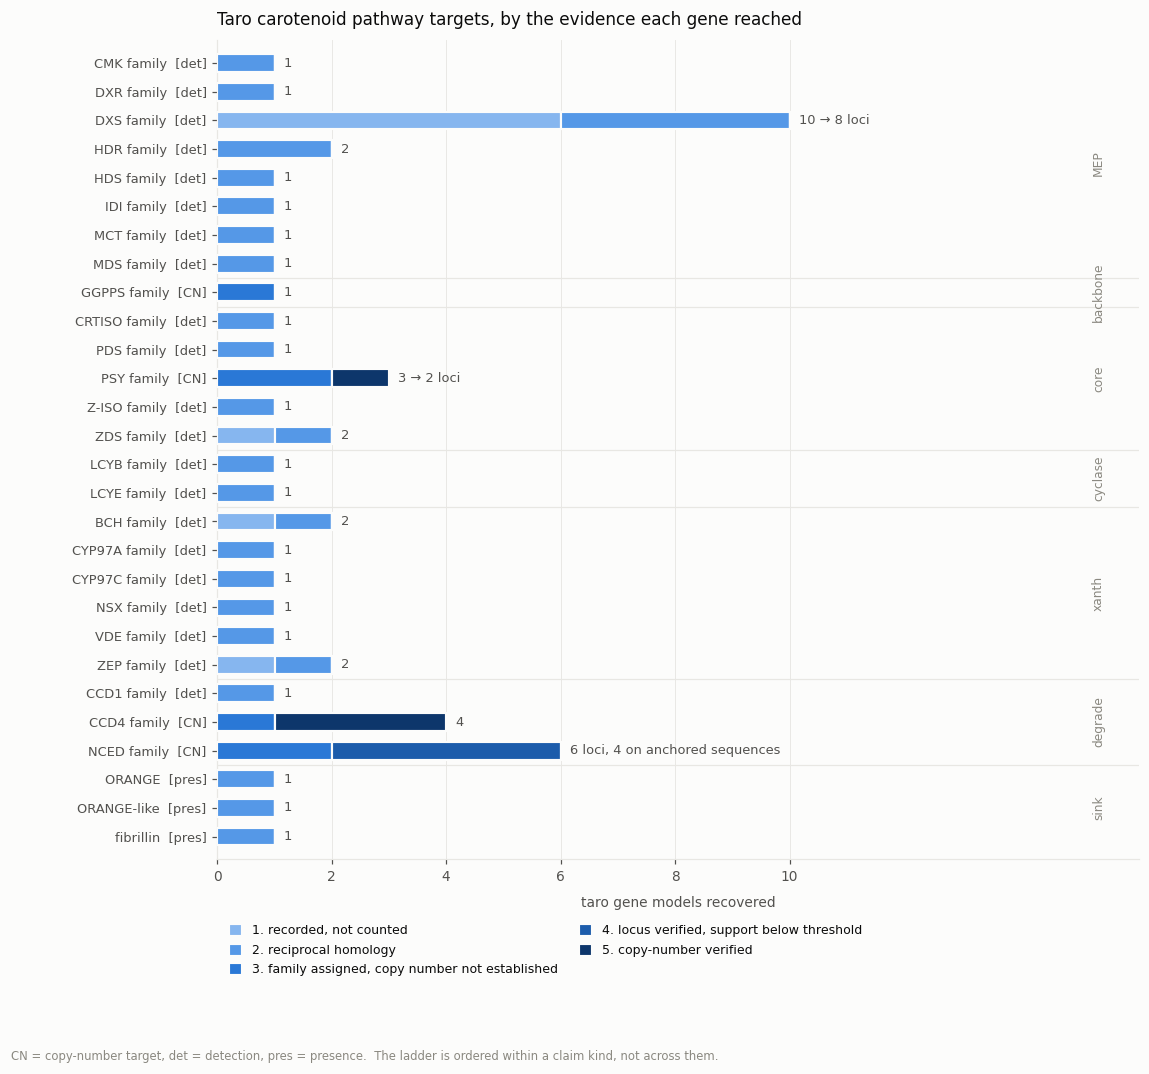

In [19]:
KIND = {'copy-number': 'CN', 'detection': 'det', 'presence': 'pres'}
order = ORDER

counts = (inv.groupby(['target', 'tier']).size().unstack(fill_value=0)
             .reindex(order.target).reindex(columns=range(len(TIERS)), fill_value=0))

# Two different reasons a model does not contribute a countable locus, and they
# must not share a notation. "shared with" means two models ARE one locus.
# "unanchored" means it is its own locus but cannot be counted, because in a
# 1.83% heterozygous assembly a haplotig cannot be told from a paralog.
ln = inv.locus_note.fillna('')
shared = ln.str.startswith('shared').groupby(inv.target).sum().reindex(order.target)
unanch = ln.eq('unanchored sequence').groupby(inv.target).sum().reindex(order.target)

fig, ax = plt.subplots(figsize=(10.6, 9.8))
left = np.zeros(len(order))
for i in range(len(TIERS)):
    v = counts[i].values
    ax.barh(np.arange(len(order)), v, left=left, height=0.62,
            color=LADDER[i], edgecolor=SURFACE, linewidth=1.4,
            label=f'{i+1}. {TIERS[i][0]}', zorder=3)
    left += v

for y, tot in enumerate(left):
    n, s, u = int(tot), int(shared.iloc[y]), int(unanch.iloc[y])
    if s and u:
        txt = f'{n} \u2192 {n - s} loci, {n - s - u} countable'
    elif s:
        txt = f'{n} \u2192 {n - s} loci'
    elif u:
        txt = f'{n} loci, {n - u} on anchored sequences'
    else:
        txt = f'{n}'
    ax.text(tot + 0.16, y, txt, va='center', ha='left',
            fontsize=8.5, color=INK_2, zorder=4)

labels = [f'{t}  [{KIND[k]}]' for t, k in zip(order.target, order.claim_kind)]
ax.set_yticks(np.arange(len(order)), labels, fontsize=8.5)
ax.set_ylim(-0.8, len(order) - 0.2)

x_max = left.max()
x_group = x_max + 5.4
ax.set_xlim(0, x_max + 6.1)
ax.set_xticks(np.arange(0, x_max + 1, 2))
ax.set_xlabel('taro gene models recovered', labelpad=8)
ax.xaxis.grid(True, linewidth=0.6, zorder=0)
ax.set_axisbelow(True)

prev, bounds = None, []
for y, p in enumerate(order.pathway):
    if prev is not None and p != prev:
        bounds.append(y - 0.5)
    prev = p
for b in bounds:
    ax.axhline(b, color=GRID, linewidth=0.8, zorder=1)

for p in PATH_ORDER:
    ys = np.asarray(order.index[order.pathway == p])
    if ys.size:
        ax.text(x_group, ys.mean(), p, rotation=90, va='center', ha='center',
                fontsize=8, color=INK_MUTED, zorder=4)

ax.set_title('Taro carotenoid pathway targets, by the evidence each gene reached')
ax.legend(loc='upper left', bbox_to_anchor=(0.0, -0.065), ncols=2,
          fontsize=8.2, labelspacing=0.5, columnspacing=1.6,
          handlelength=1.1, handleheight=1.1)
fig.text(0.013, 0.004,
         'CN = copy-number target, det = detection, pres = presence.  '
         'The ladder is ordered within a claim kind, not across them.',
         fontsize=7.6, color=INK_MUTED)
fig.subplots_adjust(left=0.19, right=0.98, top=0.95, bottom=0.19)
plt.show()

## Figure 2. Support for the copy-number assignments

The twelve taro genes in the four copy-number families, with the support of the
node that assigns each one. Both statistics must clear their threshold:
**SH-aLRT at least 80 and UFBoot at least 95**, declared before the data.

Family *membership* is not what is plotted and is not in doubt: every one of
these genes is a family member at the support of its job's root-group split,
which is SH-aLRT 97.5 / UFBoot 100 for the CCD job and 100 / 100 for GGPPS and
PSY. What is plotted is the narrower question of which group inside the family
each gene belongs to.

The pattern is the whole reason NCED does not get a copy number. SH-aLRT
clears almost everywhere; UFBoot splits the genes into two groups, and the
split is not where a hopeful reading would put it.

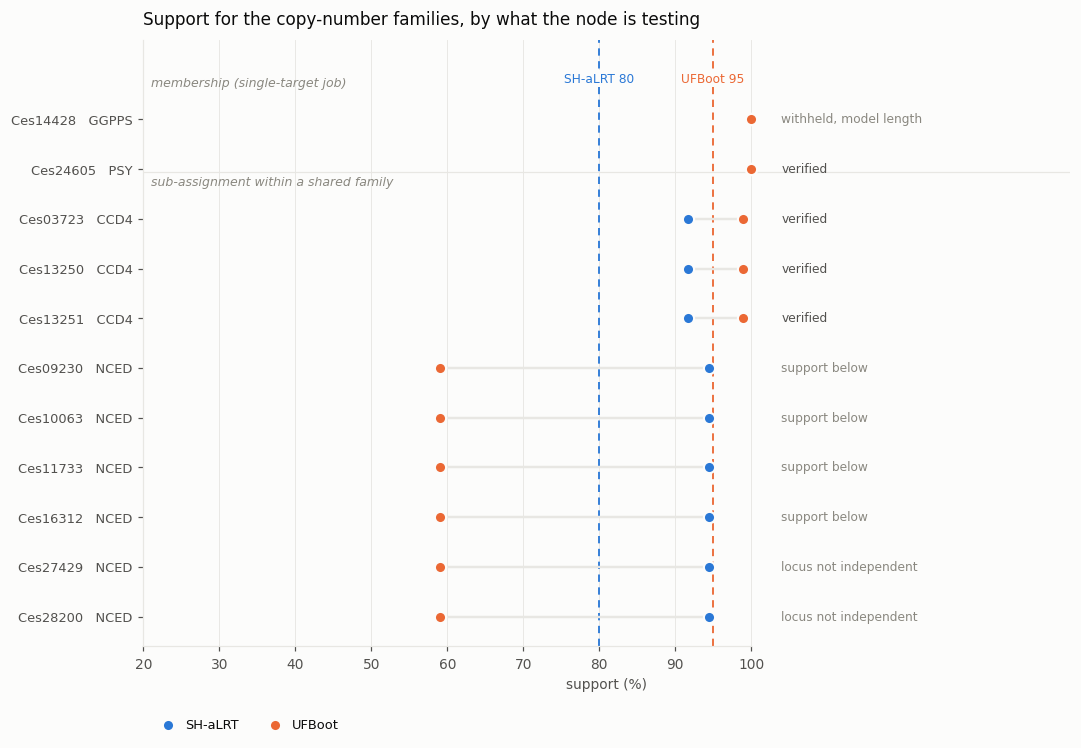

In [17]:
cn = inv[(inv.claim_kind == 'copy-number') & inv.tree_alrt.notna()].copy()

# A single-target job has no sub-assignment to make, so 04b_ recorded the
# membership support from the root-group split in these columns. That is also
# why those rows show one dot: the two values are identical.
cn['kind'] = np.where(cn.family_group.fillna('').eq(''),
                      'membership (single-target job)',
                      'sub-assignment within a shared family')
cn = cn.sort_values(['kind', 'target', 'tree_boot', 'taro_gene'],
                    ascending=[True, True, False, True]).reset_index(drop=True)
y = np.arange(len(cn))

# The verdict comes from the inventory's evidence column, not from recomputing
# the support test. Ces14428 clears support and its copy number is withheld on
# the model-length flag; printing "clears" for it would contradict the table.
def verdict(r):
    if r.evidence == 'copy-number verified':
        return 'verified', INK_2
    if r.length_flag == 1:
        return 'withheld, model length', INK_MUTED
    if str(r.evidence).startswith('locus verified'):
        return 'support below', INK_MUTED
    if str(r.evidence).startswith('family assigned'):
        return 'locus not independent', INK_MUTED
    return 'not called', INK_MUTED

fig, ax = plt.subplots(figsize=(10.4, 0.46 * len(cn) + 2.6))
ax.axvline(80, color=S1, linewidth=1.2, linestyle=(0, (4, 3)), zorder=1)
ax.axvline(95, color=S2, linewidth=1.2, linestyle=(0, (4, 3)), zorder=1)
ax.text(80, -0.95, 'SH-aLRT 80', color=S1, fontsize=8, ha='center', va='top',
        bbox=dict(facecolor=SURFACE, edgecolor='none', pad=1.5), zorder=6)
ax.text(95, -0.95, 'UFBoot 95', color=S2, fontsize=8, ha='center', va='top',
        bbox=dict(facecolor=SURFACE, edgecolor='none', pad=1.5), zorder=6)

for i, r in cn.iterrows():
    ax.plot([min(r.tree_alrt, r.tree_boot), max(r.tree_alrt, r.tree_boot)],
            [i, i], color=GRID, linewidth=1.6, zorder=2, solid_capstyle='round')
ax.scatter(cn.tree_alrt, y, s=54, color=S1, edgecolor=SURFACE, linewidth=1.4,
           zorder=4, label='SH-aLRT')
ax.scatter(cn.tree_boot, y, s=54, color=S2, edgecolor=SURFACE, linewidth=1.4,
           zorder=5, label='UFBoot')

ax.set_yticks(y, [f'{r.taro_gene}   {r.target.replace(" family", "")}'
                  for _, r in cn.iterrows()], fontsize=8.5)
ax.set_ylim(len(cn) - 0.4, -1.6)
ax.set_xlim(20, 142)
ax.set_xticks(np.arange(20, 101, 10))
ax.set_xlabel('support (%)')
ax.xaxis.grid(True, linewidth=0.6, zorder=0)
ax.set_axisbelow(True)
ax.spines['bottom'].set_bounds(20, 100)

for i, r in cn.iterrows():
    txt, col = verdict(r)
    ax.text(104, i, txt, va='center', ha='left', fontsize=8,
            color=col, zorder=4)

for k in cn.kind.unique():
    rows = cn.index[cn.kind == k]
    ax.text(21, rows.min() - 0.72, k, fontsize=8.2, color=INK_MUTED,
            va='center', ha='left', style='italic')
    if rows.min() > 0:
        ax.axhline(rows.min() - 0.95, color=GRID, linewidth=0.8, zorder=1)

ax.set_title('Support for the copy-number families, by what the node is testing')
ax.legend(loc='upper left', bbox_to_anchor=(0.0, -0.10), ncols=2,
          fontsize=8.5, handletextpad=0.3, columnspacing=1.8)
fig.subplots_adjust(left=0.17, right=0.98, bottom=0.16)
plt.show()

## Figure 3. Where each model sits on its anchor

The evidence that distinguishes one gene broken across two annotation records
from two separate genes, drawn directly. Each bar is the stretch of the
Arabidopsis anchor protein that a taro model aligns to.

Two pieces of one gene cover **different** parts of the anchor and run in the
same order as their genomic positions. Two separate genes cover the **same**
part twice. No measure of genomic distance can make that distinction, which
matters here because mean gene spacing in this annotation is 82 kb, so two
models tens of kilobases apart with nothing between them is unremarkable.

Ces13250 and Ces13251 are the case worth looking at: 75 kb apart, same strand,
nothing annotated between, and they cover the same 412 residues. Two loci.

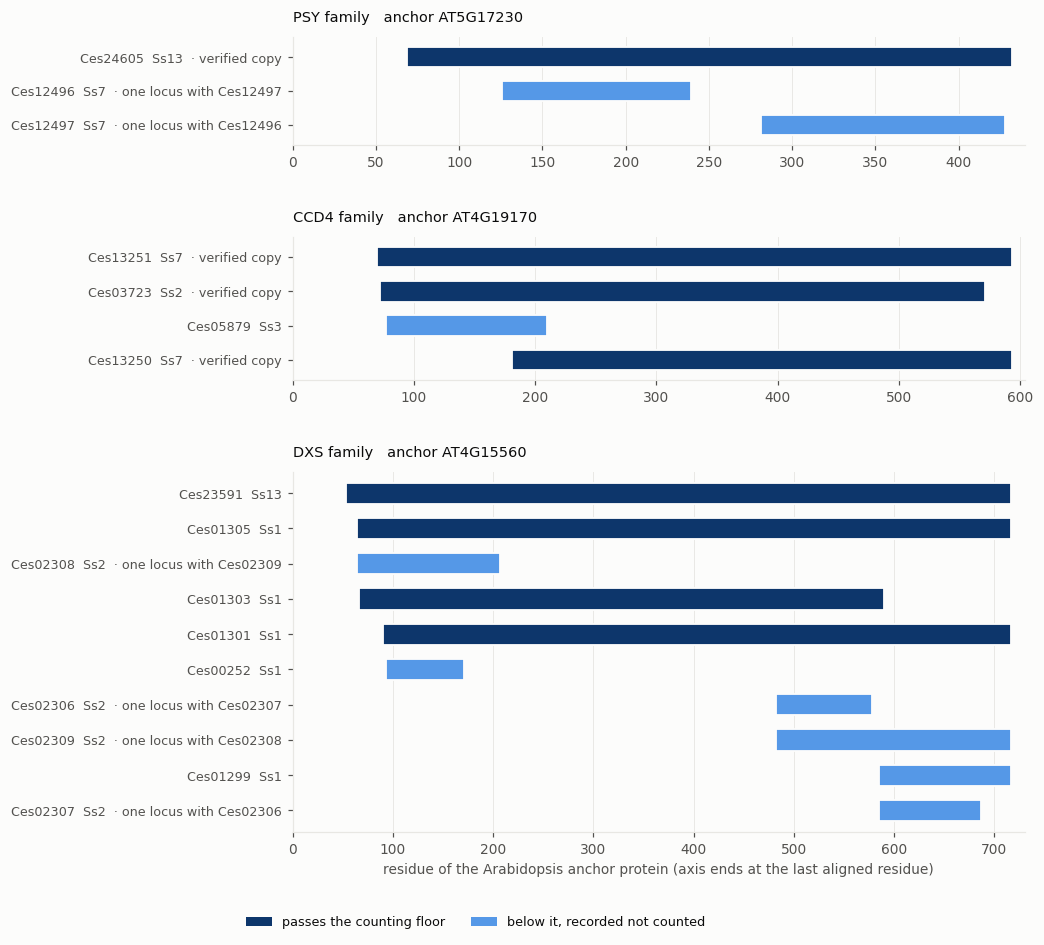

In [18]:
show = ['PSY family', 'CCD4 family', 'DXS family']
sub = inv[inv.target.isin(show)].copy()
sub['alen'] = sub.anchor_to - sub.anchor_from + 1

fig, axes = plt.subplots(len(show), 1, figsize=(10.4, 8.6),
                         gridspec_kw={'height_ratios':
                                      [sub.target.eq(t).sum() for t in show],
                                      'hspace': 0.45})
for ax, tgt in zip(np.atleast_1d(axes), show):
    d = (sub[sub.target == tgt]
         .sort_values(['anchor_from', 'taro_gene']).reset_index(drop=True))
    span = int(d.anchor_to.max())
    ticks = []
    for i, r in d.iterrows():
        ax.barh(i, r.alen, left=r.anchor_from, height=0.6,
                color=LADDER[4] if r.counted == 1 else LADDER[1],
                edgecolor=SURFACE, linewidth=1.2, zorder=3)
        tag = f"{r.taro_gene}  {r.seq.replace('Superscaffold', 'Ss')}"
        note = str(r.notes)
        # Name the partner, and mark the verified copies. Without both, the
        # overlapping CCD4 bars read as ambiguity rather than as the result.
        if 'split model' in note:
            partner = note.split('same locus as ')[-1].split(',')[0]
            tag += f'  \u00b7 one locus with {partner}'
        elif r.evidence == 'copy-number verified':
            tag += '  \u00b7 verified copy'
        ticks.append(tag)
    ax.set_yticks(range(len(d)), ticks, fontsize=8.3)
    ax.set_ylim(len(d) - 0.4, -0.6)
    ax.set_xlim(0, span * 1.02)
    ax.xaxis.grid(True, linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)
    ax.set_title(f"{tgt}   anchor {d.anchor_locus.iloc[0]}", fontsize=9.5)

np.atleast_1d(axes)[-1].set_xlabel(
    'residue of the Arabidopsis anchor protein '
    '(axis ends at the last aligned residue)')
leg = [Patch(facecolor=LADDER[4], label='passes the counting floor'),
       Patch(facecolor=LADDER[1], label='below it, recorded not counted')]
fig.legend(handles=leg, loc='lower center', bbox_to_anchor=(0.5, -0.005),
           ncols=2, fontsize=8.4)
fig.subplots_adjust(left=0.34, right=0.98, top=0.95, bottom=0.11)
plt.show()

## Figure 4. Does the candidate set survive the thresholds?

Reciprocal-best-hit counts across nine combinations of alignment length and
query coverage. None of these thresholds has a principled justification; they
are conventional, which is the reason for sweeping them rather than defending
them. A row that changes along its length is reporting a property of the cutoff.

Two features of the sweep itself are visible and are reported rather than
tuned away. The **200 aa alignment floor exceeds the length of some pathway
proteins**, so MDS and NSX cannot meet it with a complete alignment. The **80%
coverage tier sits above where genuine ortholog pairs at this divergence land**,
which is why six single-copy targets drop to zero in those columns and nowhere
else. Strip both artifacts and two targets are genuinely threshold-dependent:
DXS and CCD4.

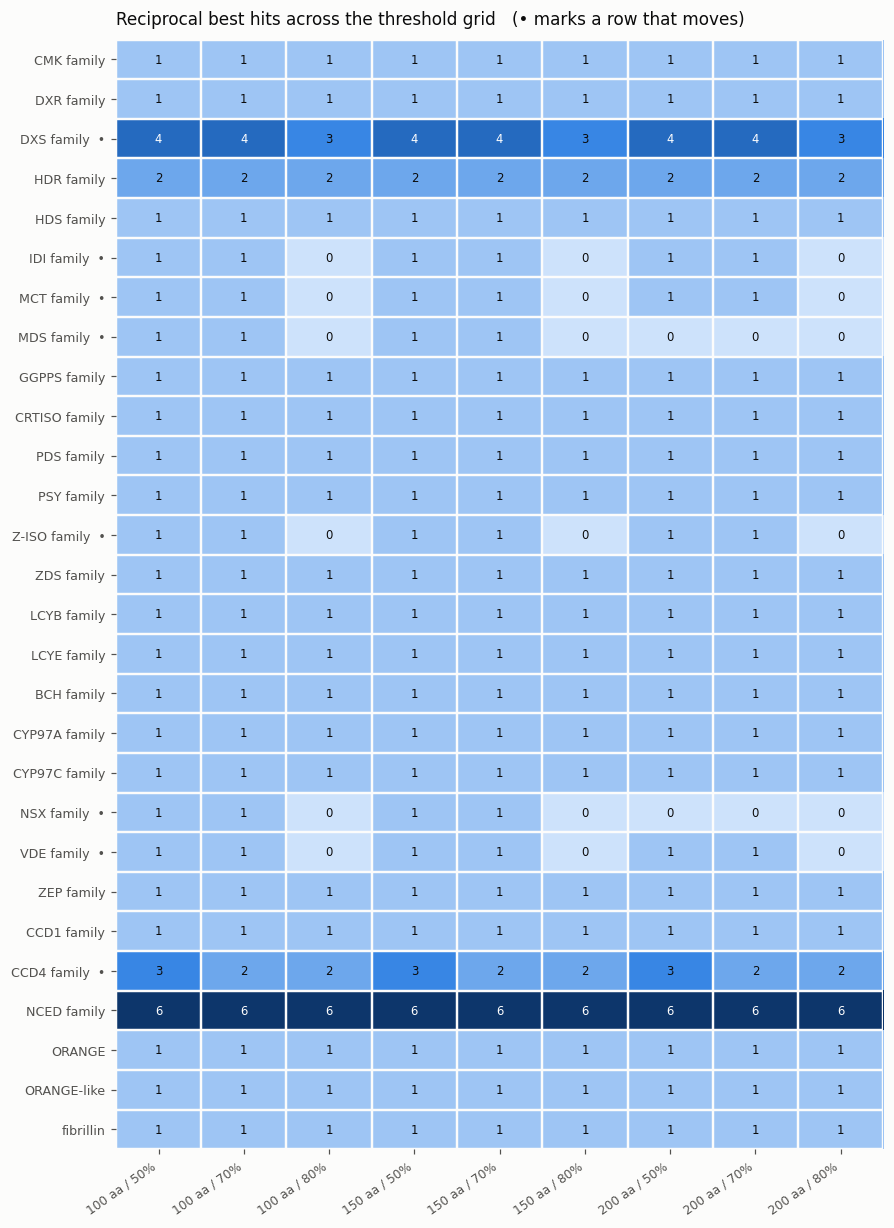

In [6]:
cols = [c for c in sens.columns if c.startswith('aln')]
M = sens.set_index('target')[cols]
M = M.reindex([t for t in ORDER.target[::-1] if t in M.index])

fig, ax = plt.subplots(figsize=(8.2, 0.33 * len(M) + 2.0))
im = ax.imshow(M.values, cmap=SEQ, aspect='auto',
               vmin=0, vmax=max(1, M.values.max()))
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        v = M.values[i, j]
        ax.text(j, i, str(int(v)), ha='center', va='center', fontsize=7.6,
                color='#ffffff' if v > M.values.max() * 0.55 else INK)

pretty = [c.replace('aln', '').replace('_cov', ' aa / ') + '%' for c in cols]
ax.set_xticks(range(len(cols)), pretty, fontsize=8, rotation=35, ha='right')
unstable = set(sens.loc[~sens.stable.astype(bool), 'target'])
ax.set_yticks(range(len(M)),
              [f'{t}  \u2022' if t in unstable else t for t in M.index],
              fontsize=8.3)
ax.set_xticks(np.arange(-.5, len(cols), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(M), 1), minor=True)
ax.grid(which='minor', color=SURFACE, linewidth=1.6)
ax.tick_params(which='minor', length=0)
for s in ax.spines.values():
    s.set_visible(False)
ax.set_title('Reciprocal best hits across the threshold grid'
             '   (\u2022 marks a row that moves)')
plt.tight_layout()
plt.show()

## What these figures do not show

- **No copy number for a detection target.** Twenty-one of the twenty-eight
  carry lower bounds only, and figure 1's bar length is a gene count, never a
  copy number.
- **No PSY subgroup.** Two analyses reached opposite conclusions and neither
  cleared support, so it is recorded as not determinable in
  `docs/open_questions.md` and no third attempt was made.
- **No statistical test across species.** Tips on a tree are not independent
  samples, so a test comparing copy number between species would be
  phylogenetic pseudoreplication. Counts from other species appear in the
  methods as a cross-check against published values, not as a comparison.
- **No expression.** Everything here is genomic. Whether a locus is
  transcribed, and in which tissue, is Part 2.
- **One annotation.** Every count is a count in `Colocasia_esculenta.Genome.V1`.
  A second annotation reports 56,238 genes against this one's 28,253, and
  reconciling them is its own question.